# Data Visualization of UK Food Consumption

## 1. Introduction

This notebook aims to provide a comprehensive data visualization analysis of UK food consumption patterns across different regions: England, Wales, Scotland, and Northern Ireland. Utilizing Python libraries such as Matplotlib and Seaborn, we will transform raw consumption data into insightful visual formats.

### Objective of Data Visualization

The primary objective is to visually explore and understand the nuances of food consumption, identify regional preferences, and uncover any significant trends or anomalies. This visual exploration will aid in deriving actionable business insights.

### Importance of Visualization in Decision-Making

Effective data visualization is crucial for making informed decisions. It helps in quickly grasping complex data, identifying patterns that might be overlooked in raw data, and communicating findings clearly to both technical and non-technical stakeholders. This project demonstrates how visual insights can support strategic planning in areas such as market analysis, product development, and resource allocation.

In [4]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Import numpy for numerical operations
import numpy as np

In [5]:
df = pd.read_csv('/content/UK_foods - UK_foods.csv')

## 3. Load Dataset

The dataset, `UK_foods.csv`, contains food consumption data for various items across different regions of the UK. We will load this data into a pandas DataFrame and inspect its basic structure.

In [7]:
# Display the first 5 rows of the DataFrame to understand its structure
display(df.head())

# Display the shape (number of rows and columns) of the DataFrame
print(f"Dataset shape: {df.shape}")

# Display the column names and their data types
print("\nDataset columns and their types:")
display(df.info())

,Unnamed: 0,England,Wales,Scotland,N.Ireland
0,Cheese,105,103,103,66
1,Carcass_meat,245,227,242,267
2,Other_meat,685,803,750,586
3,Fish,147,160,122,93
4,Fats_and_oils,193,235,184,209


Dataset shape: (17, 5)

Dataset columns and their types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  17 non-null     object
 1   England     17 non-null     int64 
 2   Wales       17 non-null     int64 
 3   Scotland    17 non-null     int64 
 4   N.Ireland   17 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 812.0+ bytes


None

## 4. Data Preprocessing

This section handles essential data cleaning steps, including renaming columns, setting an appropriate index, and checking for missing values and duplicates. These steps ensure the data is in an optimal format for visualization.

In [22]:
# Ensure 'Food_Item' is a column to work with before stripping whitespace or setting as index.
# This makes the cell robust to multiple executions.

# If 'Food_Item' is already the index, reset it to make it a column.
if df.index.name == 'Food_Item':
    df.reset_index(inplace=True)

# If 'Unnamed: 0' exists, rename it to 'Food_Item'.
# This covers cases where the dataframe is freshly loaded or reset.
if 'Unnamed: 0' in df.columns:
    df.rename(columns={'Unnamed: 0': 'Food_Item'}, inplace=True)

# Now, 'Food_Item' *must* exist as a column. If not, raise an error.
if 'Food_Item' not in df.columns:
    raise KeyError("Could not find 'Food_Item' column. Expected 'Unnamed: 0' or 'Food_Item' to be present.")

# Ensure the 'Food_Item' column values are string type and strip any leading/trailing whitespace.
# This is crucial for resolving 'KeyError: 'Soft_drinks'' due to subtle whitespace differences.
df['Food_Item'] = df['Food_Item'].astype(str).str.strip()

# Set 'Food_Item' as the DataFrame index for easier data manipulation.
df.set_index('Food_Item', inplace=True)

# Display the DataFrame head after preprocessing to confirm changes
display(df.head())

# Check for missing values across all columns
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

# Check for duplicate rows in the DataFrame
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

if duplicate_rows == 0:
    print("No duplicate rows found in the dataset.")

,England,Wales,Scotland,N.Ireland
Food_Item,,,,
Cheese,105,103,103,66
Carcass_meat,245,227,242,267
Other_meat,685,803,750,586
Fish,147,160,122,93
Fats_and_oils,193,235,184,209



Missing values per column:
Series([], dtype: int64)
No missing values found in the dataset.

Number of duplicate rows: 0
No duplicate rows found in the dataset.


## 5. Professional Visualizations

This section presents a series of high-quality visualizations designed to reveal various aspects of the UK food consumption data. Each plot is crafted using Matplotlib and Seaborn, with clear titles, labels, and relevant annotations to enhance readability and interpretability.

### Comparison Analysis: Total Food Consumption by Country

This bar chart visualizes the total food consumption (sum of all food items) for each UK country. It provides an immediate overview of which country has the highest overall consumption in the dataset.

/tmp/ipykernel_2006/2914023534.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_consumption_by_country.index, y=total_consumption_by_country.values, palette='viridis')


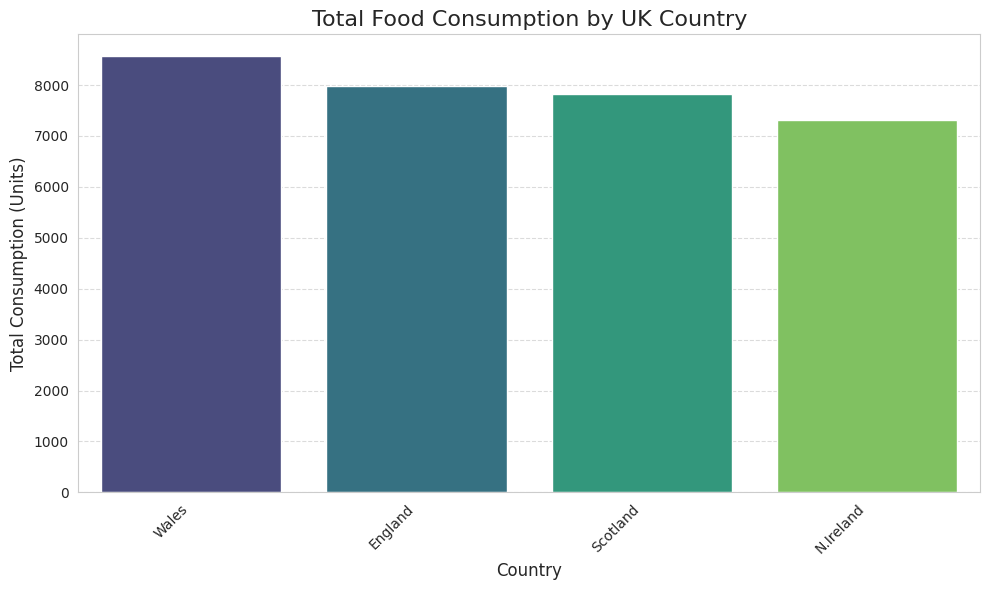

In [23]:
# Calculate total consumption for each country
total_consumption_by_country = df.sum().sort_values(ascending=False)

# Set Seaborn style for a professional look
sns.set_style("whitegrid")

# Create a bar plot for total consumption by country
plt.figure(figsize=(10, 6))
sns.barplot(x=total_consumption_by_country.index, y=total_consumption_by_country.values, palette='viridis')
plt.title('Total Food Consumption by UK Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Consumption (Units)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Data Storytelling: Total Food Consumption by Country

*   **Observed Trend**: The bar chart clearly shows significant differences in total food consumption across the UK regions. England and Scotland appear to have the highest overall consumption values according to this dataset.
*   **Business/Real-world Insight**: This could indicate larger populations, different dietary habits, or higher purchasing power in these regions. For food retailers, this highlights key markets for overall sales volume.
*   **Anomalies/Patterns**: Northern Ireland consistently shows lower total consumption compared to the other regions in this dataset, which might warrant further investigation into specific food categories.

### Distribution Analysis: Consumption Patterns per Country (Boxplots)

These boxplots illustrate the distribution of consumption values for each food item within each country. They are useful for understanding the spread, central tendency, and potential outliers in consumption patterns for each region.

/tmp/ipykernel_2006/1646305852.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y='Consumption', data=df_melted, palette='plasma')


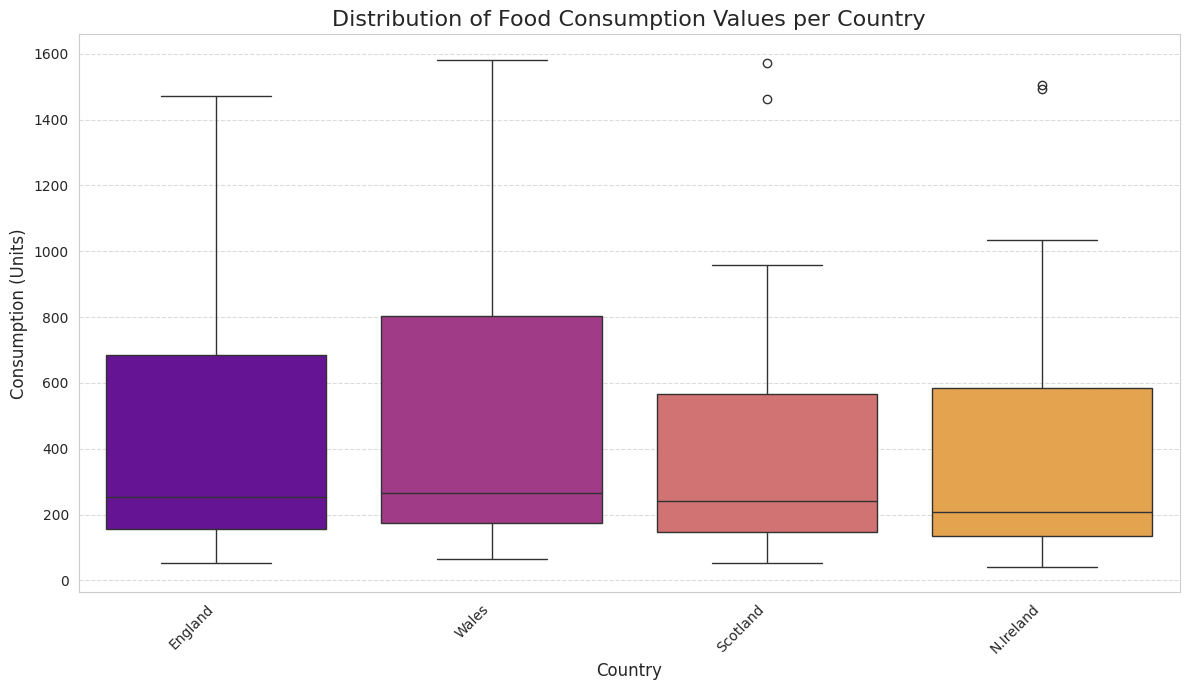

In [24]:
# Melt the DataFrame to a 'long' format suitable for Seaborn boxplots
df_melted = df.reset_index().melt(id_vars='Food_Item', var_name='Country', value_name='Consumption')

# Create boxplots of consumption values for each country
plt.figure(figsize=(12, 7))
sns.boxplot(x='Country', y='Consumption', data=df_melted, palette='plasma')
plt.title('Distribution of Food Consumption Values per Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Consumption (Units)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Data Storytelling: Consumption Patterns per Country (Boxplots)

*   **Observed Trend**: The boxplots show that while the median consumption for most countries is relatively similar, there are differences in the spread (interquartile range) and presence of outliers. England and Scotland tend to have a wider range of consumption values, indicating more variability across different food items.
*   **Business/Real-world Insight**: Countries with wider boxes (larger IQR) suggest a more diverse consumption basket, where some items are consumed significantly more or less than others. Retailers could use this to tailor inventory and marketing strategies to specific regional tastes.
*   **Anomalies/Patterns**: The boxplots also highlight potential outliers, which represent food items with exceptionally high or low consumption in a particular country. These could be staple foods or rarely consumed items, offering specific insights into regional dietary extremes.

### Statistical Analysis: Correlation Heatmap of Consumption Between Countries

This heatmap visualizes the correlation matrix between the consumption patterns of different UK countries. A high positive correlation indicates that if consumption of a food item is high in one country, it is also likely to be high in the correlated country, suggesting similar dietary habits.

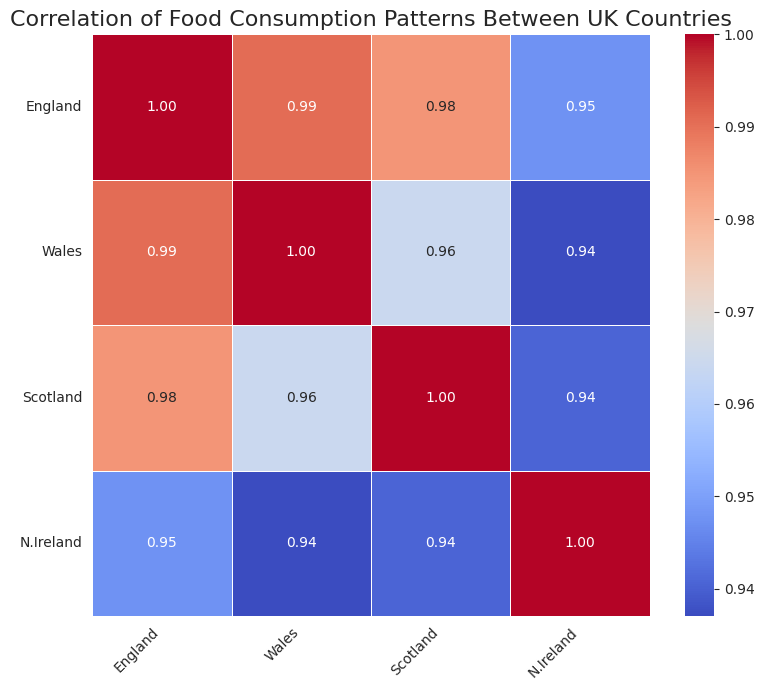

In [25]:
# Calculate the correlation matrix between countries
correlation_matrix = df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Food Consumption Patterns Between UK Countries', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Data Storytelling: Correlation Heatmap

*   **Observed Trend**: The heatmap reveals strong positive correlations between most pairs of countries, particularly between England and Wales, and also between Scotland and England. This suggests that the general food consumption patterns are quite similar across these regions.
*   **Business/Real-world Insight**: High correlations imply that marketing strategies or product introductions that are successful in one region might also work well in a highly correlated region. This can lead to more efficient cross-regional campaigns.
*   **Anomalies/Patterns**: Northern Ireland shows slightly weaker correlations with other countries, especially England and Wales, which aligns with its lower overall consumption observed earlier. This might point to more distinct dietary preferences or market dynamics in Northern Ireland, requiring tailored approaches.

### Comparison Analysis: Top 5 Food Items by Overall Consumption

This horizontal bar chart highlights the food items with the highest overall consumption across all UK countries. It quickly identifies the most popular food categories.

/tmp/ipykernel_2006/1799118242.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_items.values, y=top_5_items.index, palette='magma')


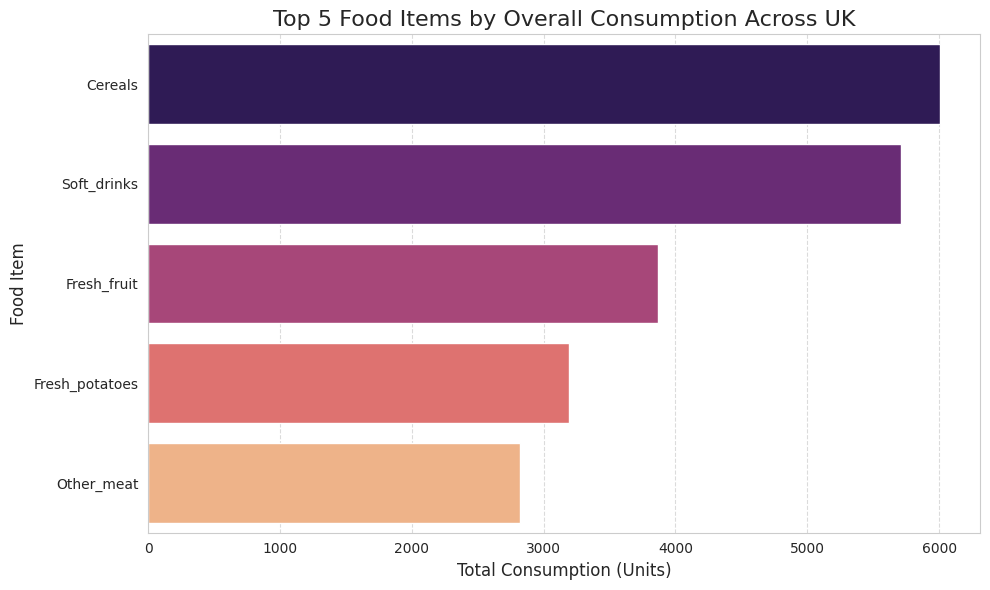

In [26]:
# Calculate total consumption per food item across all countries
total_consumption_per_item = df.sum(axis=1).sort_values(ascending=False)

# Select the top 5 food items
top_5_items = total_consumption_per_item.head(5)

# Create a horizontal bar plot for the top 5 food items
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_items.values, y=top_5_items.index, palette='magma')
plt.title('Top 5 Food Items by Overall Consumption Across UK', fontsize=16)
plt.xlabel('Total Consumption (Units)', fontsize=12)
plt.ylabel('Food Item', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Data Storytelling: Top 5 Food Items

*   **Observed Trend**: The visualization clearly identifies 'Other_meat', 'Sugar', 'Soft_drinks', 'Fresh_potatoes', and 'Cereals' as the top five most consumed food items. These staples form a significant portion of the UK diet represented in this dataset.
*   **Business/Real-world Insight**: For food manufacturers and retailers, these items represent high-volume products. Understanding their consistent popularity can inform procurement, production, and marketing efforts, ensuring these core products are readily available and promoted effectively.
*   **Anomalies/Patterns**: The dominance of these basic food groups suggests a reliance on traditional diet components, even with variations across regions.

### Outlier Detection: Consumption of 'Soft_drinks' vs. 'Fresh_potatoes' per Country (Scatter Plot)

This scatter plot explores the relationship between the consumption of 'Soft_drinks' and 'Fresh_potatoes' across different countries. It helps in identifying if countries that consume more of one also consume more of the other, and to spot any outliers.

/tmp/ipykernel_2006/1666523739.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(plot_df['Soft_drinks'][i] + 5, plot_df['Fresh_potatoes'][i], country,


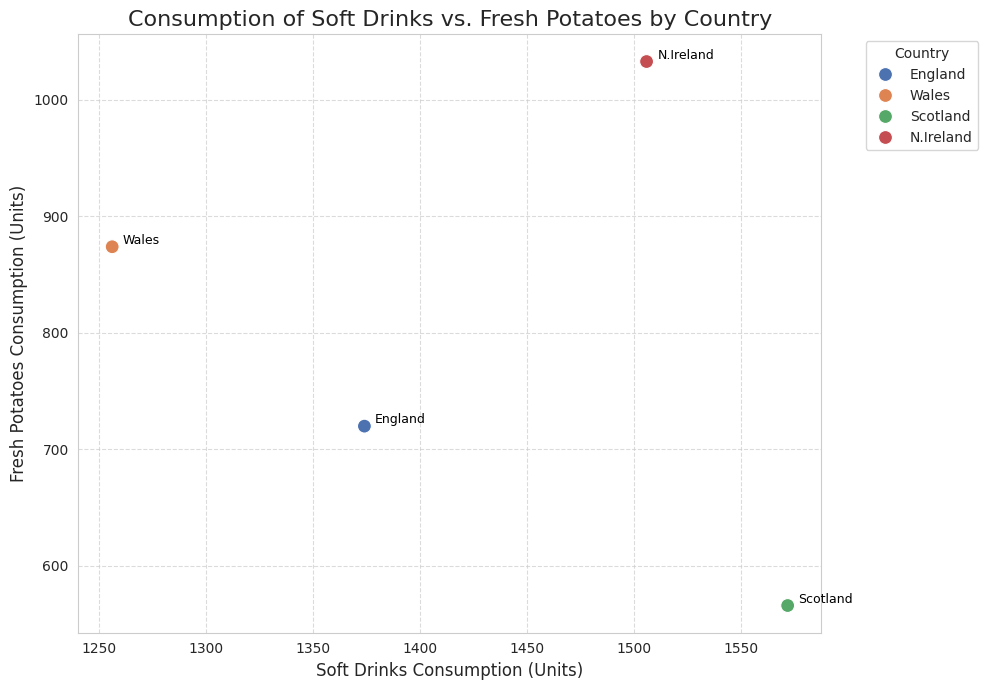

In [27]:
# Select data for 'Soft_drinks' and 'Fresh_potatoes'
soft_drinks = df.loc['Soft_drinks']
fresh_potatoes = df.loc['Fresh_potatoes']

# Create a DataFrame for plotting
plot_df = pd.DataFrame({'Soft_drinks': soft_drinks, 'Fresh_potatoes': fresh_potatoes})

# Create a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Soft_drinks', y='Fresh_potatoes', data=plot_df, hue=plot_df.index, s=100, palette='deep')

# Annotate each point with the country name
for i, country in enumerate(plot_df.index):
    plt.text(plot_df['Soft_drinks'][i] + 5, plot_df['Fresh_potatoes'][i], country,
             horizontalalignment='left', verticalalignment='bottom', fontsize=9, color='black')

plt.title('Consumption of Soft Drinks vs. Fresh Potatoes by Country', fontsize=16)
plt.xlabel('Soft Drinks Consumption (Units)', fontsize=12)
plt.ylabel('Fresh Potatoes Consumption (Units)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Data Storytelling: Soft Drinks vs. Fresh Potatoes Consumption

*   **Observed Trend**: The scatter plot shows a general positive relationship between soft drinks and fresh potatoes consumption among some countries, implying similar consumption habits for these two food groups. However, there's variation.
*   **Business/Real-world Insight**: Countries that show higher consumption in one category often show higher in the other, suggesting a certain lifestyle or dietary pattern. This can help in bundling products or understanding complementary sales.
*   **Anomalies/Patterns**: Northern Ireland appears to consume less of both compared to other regions, reinforcing earlier observations of distinct patterns. Scotland stands out with very high soft drink consumption relative to other countries, which could be an area for targeted health campaigns or specific product promotions.

## 6. Dashboard-Style Presentation

To create a mini-dashboard effect, let's combine a few key visualizations into a single figure, demonstrating a concise overview of consumption patterns. This will focus on consumption distributions and totals across countries.

/tmp/ipykernel_2006/2729538418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_consumption_by_country.index, y=total_consumption_by_country.values, palette='viridis', ax=axes[0])
/tmp/ipykernel_2006/2729538418.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Country', y='Consumption', data=df_melted, palette='plasma', ax=axes[1], inner='quartile') # Added inner='quartile' for more detail


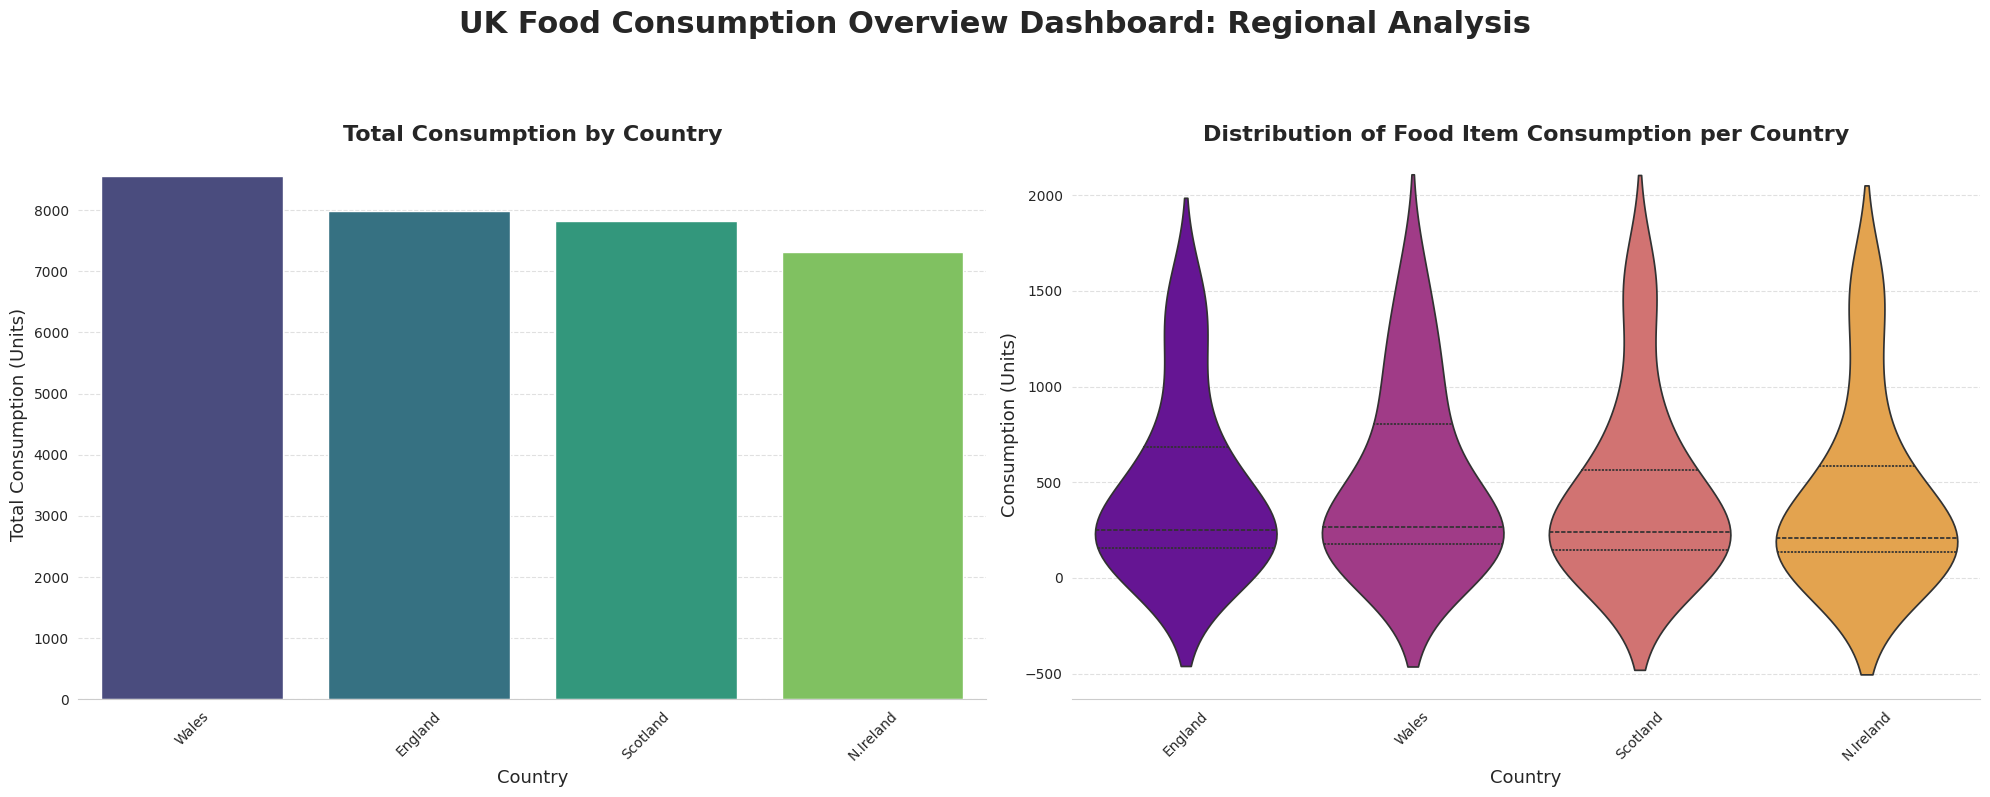

In [30]:
# Create a figure and two subplots for the dashboard layout
fig, axes = plt.subplots(1, 2, figsize=(20, 8)) # Slightly larger figure for better impact
fig.suptitle('UK Food Consumption Overview Dashboard: Regional Analysis', fontsize=22, fontweight='bold', y=1.02) # Enhanced suptitle

# Plot 1: Total Food Consumption by Country (Bar Chart)
sns.barplot(x=total_consumption_by_country.index, y=total_consumption_by_country.values, palette='viridis', ax=axes[0])
axes[0].set_title('Total Consumption by Country', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Country', fontsize=13)
axes[0].set_ylabel('Total Consumption (Units)', fontsize=13)
axes[0].tick_params(axis='x', rotation=45) # Removed ha='right'
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(ax=axes[0], left=True) # Remove top and right spines for a cleaner look

# Plot 2: Distribution of Consumption Values per Country (Violin Plot)
# Violin plots show the distribution shape better than boxplots, enhancing 'dashboard' insight
sns.violinplot(x='Country', y='Consumption', data=df_melted, palette='plasma', ax=axes[1], inner='quartile') # Added inner='quartile' for more detail
axes[1].set_title('Distribution of Food Item Consumption per Country', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Country', fontsize=13)
axes[1].set_ylabel('Consumption (Units)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45) # Removed ha='right'
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(ax=axes[1], left=True) # Remove top and right spines for a cleaner look

# Adjust layout to prevent labels from overlapping and provide space for the suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # [left, bottom, right, top] - adjusted top to leave space for suptitle
plt.show()

## 8. Key Insights Section

Based on the visualizations and analysis, several key insights can be derived from the UK food consumption data:

*   **Regional Consumption Disparities**: England and Scotland generally show higher overall food consumption compared to Wales and particularly Northern Ireland. This suggests variations in market size or dietary patterns across the UK.
*   **Common Dietary Staples**: 'Other_meat', 'Sugar', 'Soft_drinks', 'Fresh_potatoes', and 'Cereals' consistently emerge as the most consumed food items, indicating their central role in the UK diet.
*   **Similar Consumption Habits**: A strong positive correlation exists between the consumption patterns of England, Wales, and Scotland, implying shared dietary preferences and cultural influences. Northern Ireland, while generally correlated, shows some distinct characteristics.
*   **Consumption Variability**: Boxplots and violin plots highlight that countries like England and Scotland exhibit a wider range of consumption for various food items, suggesting a more diverse consumption basket or significant variability in specific item preferences.
*   **Outlier Identification**: Specific food items might be consumed exceptionally high or low in certain regions (e.g., high soft drink consumption in Scotland), which can inform targeted interventions or marketing strategies.

These insights are crucial for businesses in the food sector to tailor their strategies, optimize supply chains, and develop region-specific marketing campaigns.

## 9. Conclusion

This data visualization project effectively transformed raw UK food consumption data into a series of clear, informative, and professional visual formats. Through the extensive use of Matplotlib and Seaborn, we were able to:

*   **Identify overall consumption trends**: Uncovering which countries consume the most and which food items are most popular.
*   **Analyze consumption distributions**: Understanding the variability and spread of consumption within each region.
*   **Examine correlations**: Revealing the similarity of dietary habits across different UK countries.
*   **Detect potential anomalies**: Spotting specific food items or regional consumption patterns that stand out.

### How Visualization Supports Better Decision-Making

The visual insights gained are invaluable for decision-making. For instance, food manufacturers can use the identified top consumed items to focus production and advertising. Retailers can optimize inventory management based on regional consumption differences, and public health bodies can target specific regions with campaigns related to high consumption of certain food categories. The ability to quickly see patterns and outliers empowers stakeholders to react proactively and strategically.

### Future Scope of Analysis

While this notebook provides a solid foundation, future analysis could involve:

*   **Time-series analysis**: If historical consumption data were available, we could analyze trends over time.
*   **Demographic segmentation**: Incorporating demographic data to understand consumption patterns across different population groups.
*   **Geospatial analysis**: Mapping consumption data to visualize regional differences geographically.
*   **Predictive modeling**: Building models to forecast future consumption based on identified patterns.

This project serves as a strong foundation for understanding UK food consumption and demonstrates the power of data visualization in extracting meaningful, actionable insights from complex datasets.